In [1]:
# Cell 1: Import necessary libraries

import os
import cv2
import json
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tf2onnx
import onnx


In [2]:
# Cell 2: Set paths and directories

IMAGE_FOLDER = r"C:\Users\beren\Documents\paparazzi\playground\videocap_simulation_round1"
LABELS_JSON = r"C:\Users\beren\Documents\paparazzi\playground\videocap_simulation_round1_labels\results.json"
OUTPUT_FOLDER = r"C:\Users\beren\Documents\paparazzi\playground\cnn_ouput_images"
VIDEO_OUTPUT = r"C:\Users\beren\Documents\paparazzi\playground\predictions.mp4"
TEXT_OUTPUT = r"C:\Users\beren\Documents\paparazzi\playground"

os.makedirs(OUTPUT_FOLDER, exist_ok=True)


In [3]:
# Cell 3: Load labels from JSON file

with open(LABELS_JSON, "r") as f:
    labels_data = json.load(f)


In [4]:
# Cell 4: Load images and labels, convert to YUV

def load_data(image_folder, labels_data, img_size=(520, 240)):
    images, labels = [], []
    i = 0
    for filename, data in labels_data.items():
        img_path = os.path.join(image_folder, f"{filename}.jpg")
        if not os.path.exists(img_path):
            continue
        
        # Read the image
        img = cv2.imread(img_path)
        
        # Convert the image from BGR to YUV
        img_yuv = cv2.cvtColor(img, cv2.COLOR_BGR2YUV)  # Convert to YUV
        
        # Append the image to the images list
        images.append(img_yuv)

        # Save the YUV grid of the first image to a text file
        if i == 0:
            yuv_output_path = os.path.join(TEXT_OUTPUT, "first_image_yuv_grid.txt")
            with open(yuv_output_path, "w") as f:
                f.write(f"{img_yuv.tolist()}\n")
            print(f"YUV image grid of the first image saved to {yuv_output_path}")
        
        # Get the label grid
        label_grid = np.array(data["scores"])  # Safety grid
        labels.append(label_grid)
        
        i += 1
    
    return np.array(images), np.array(labels)

X, y = load_data(IMAGE_FOLDER, labels_data)
y = np.expand_dims(y, axis=-1)  # Add channel for CNN


YUV image grid of the first image saved to C:\Users\beren\Documents\paparazzi\playground\first_image_yuv_grid.txt


In [6]:
# Cell 5: Split data into training and testing

num_images = len(X)
halfway_point = num_images // 2

X_train = X[:halfway_point]
y_train = y[:halfway_point]

X_test = X[halfway_point:]
y_test = y[halfway_point:]


In [7]:
# Cell 6: Build CNN model

def build_model(optimizer='adam', conv1_filters=16, conv1_stride_y=32, conv1_stride_x=32, conv2_filters=32, conv3_filters=64):
    model = models.Sequential([ 
        layers.Conv2D(conv1_filters, (1, 1), strides=(conv1_stride_y, conv1_stride_x), activation='relu', input_shape=(240, 520, 3)),  
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(conv2_filters, (1, 1), strides=(1, 1), activation='relu'),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(conv3_filters, (1, 1), strides=(1, 1), activation='relu'),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),

        layers.Dense(128, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(y_train.shape[1] * y_train.shape[2], activation='sigmoid', name='output')
    ])

    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
    return model

model = build_model(optimizer='adam')


In [8]:
# Cell 7: Train the model with EarlyStopping callback

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

model.fit(X_train, y_train.reshape(y_train.shape[0], -1), epochs=5, batch_size=16, 
          validation_data=(X_test, y_test.reshape(y_test.shape[0], -1)),
          callbacks=[early_stopping])  


Epoch 1/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 0.1771 - mae: 0.3349 - val_loss: 0.0566 - val_mae: 0.1922
Epoch 2/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0501 - mae: 0.1805 - val_loss: 0.0438 - val_mae: 0.1659
Epoch 3/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0431 - mae: 0.1675 - val_loss: 0.0432 - val_mae: 0.1638
Epoch 4/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0429 - mae: 0.1666 - val_loss: 0.0423 - val_mae: 0.1627
Epoch 5/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0429 - mae: 0.1670 - val_loss: 0.0445 - val_mae: 0.1709
Restoring model weights from the end of the best epoch: 4.


In [9]:
# Cell 8: Make predictions

y_pred = model.predict(X_test)
y_pred = y_pred.reshape(y_test.shape)  # Reshape to grid format


25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


In [10]:
# Cell 9: Overlay safety grid onto images

def overlay_safety_grid(base_img, safety_grid, alpha=0.4):
    overlay = base_img.copy()
    h, w, _ = overlay.shape
    grid_height, grid_width, extra = safety_grid.shape
    cell_h = h // grid_height
    cell_w = w // grid_width

    for gy in range(grid_height):
        for gx in range(grid_width):
            val = float(safety_grid[gy, gx])  
            r = int((1.0 - val) * 255)
            g = int(val * 255)
            b = 0
            color = (b, g, r)
            
            y_start = gy * cell_h
            y_end   = (gy+1) * cell_h if gy < grid_height - 1 else h
            x_start = gx * cell_w
            x_end   = (gx+1) * cell_w if gx < grid_width - 1 else w

            cv2.rectangle(overlay, (x_start, y_start), (x_end, y_end), color, -1)

    blended = cv2.addWeighted(overlay, alpha, base_img, 1 - alpha, 0)
    return blended


In [11]:
# Cell 10: Save predicted images

def save_predicted_images(X_test, y_pred, y_test, output_folder):
    for i in range(len(X_test)):
        original = (X_test[i] * 255).astype(np.uint8)
        pred_overlay = overlay_safety_grid(original, y_pred[i])
        gt_overlay = overlay_safety_grid(original, y_test[i])
        
        combined = np.hstack((gt_overlay, pred_overlay))  # Side-by-side comparison
        cv2.imwrite(os.path.join(output_folder, f"pred_{i}.jpg"), combined)

save_predicted_images(X_test, y_pred, y_test, OUTPUT_FOLDER)


C:\Users\beren\AppData\Local\Temp\ipykernel_24260\937759760.py:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  val = float(safety_grid[gy, gx])


In [12]:
# Cell 11: Generate video from saved images

def create_video(image_folder, output_video, fps=1):
    images = [img for img in os.listdir(image_folder) if img.endswith(".jpg")]
    images.sort()
    
    if not images:
        print("No images found to create video.")
        return
    
    frame = cv2.imread(os.path.join(image_folder, images[0]))
    h, w, _ = frame.shape
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    video = cv2.VideoWriter(output_video, fourcc, fps, (w, h))
    
    for image in images:
        frame = cv2.imread(os.path.join(image_folder, image))
        video.write(frame)
    
    video.release()
    print(f"Video saved to {output_video}")

create_video(OUTPUT_FOLDER, VIDEO_OUTPUT)


Video saved to C:\Users\beren\Documents\paparazzi\playground\predictions.mp4


In [13]:
# Cell 12: Save and convert the model to ONNX format

model.output_names=['output']

# Save the Keras model
model.save(r"C:\Users\beren\Documents\paparazzi\playground\cnn_model.keras")

# Convert the trained model to ONNX format
onnx_model_path = r"C:\Users\beren\Documents\paparazzi\playground\cnn_model.onnx"
onnx_model, _ = tf2onnx.convert.from_keras(
    model,
    opset=13,
    input_signature=[tf.TensorSpec(shape=[None, 240, 520, 3], dtype=tf.float32)],
)

with open(onnx_model_path, "wb") as f:
    f.write(onnx_model.SerializeToString())

print("Model successfully converted to ONNX format!")


Model successfully converted to ONNX format!


In [14]:
# Cell 13: Verify the ONNX model

onnx_model = onnx.load(onnx_model_path)
onnx.checker.check_model(onnx_model)
print("ONNX model is valid.")


ONNX model is valid.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
Safety grid of first image saved to C:\Users\beren\Documents\paparazzi\playground\first_image_safety_grid.txt
Prediction on first image saved to C:\Users\beren\Documents\paparazzi\playground\first_image_prediction.jpg


C:\Users\beren\AppData\Local\Temp\ipykernel_24260\937759760.py:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  val = float(safety_grid[gy, gx])


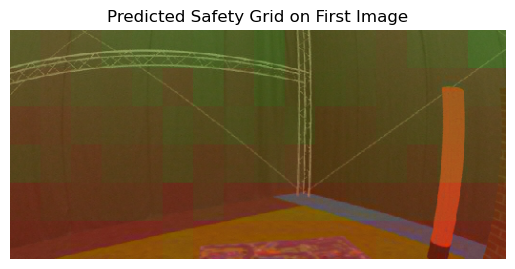

In [15]:
# Cell 14: Test model on the first image in the folder

image_files = sorted([f for f in os.listdir(IMAGE_FOLDER) if f.endswith(".jpg")])
if not image_files:
    print("No images found in the folder.")
else:
    first_image_path = os.path.join(IMAGE_FOLDER, image_files[0])

    # Load and preprocess the image
    first_img = cv2.imread(first_image_path)
    first_img_yuv = cv2.cvtColor(first_img, cv2.COLOR_BGR2YUV)
    first_img_yuv = np.expand_dims(first_img_yuv, axis=0)

    # Predict
    first_pred = model.predict(first_img_yuv)
    first_pred = first_pred.reshape(y_train.shape[1:])

    # Save the safety grid of the first image
    safety_grid_output_path = os.path.join(TEXT_OUTPUT, "first_image_safety_grid.txt")
    with open(safety_grid_output_path, "w") as f:
        f.write(f"{first_pred.tolist()}\n")
    print(f"Safety grid of first image saved to {safety_grid_output_path}")

    # Overlay safety grid
    pred_overlay = overlay_safety_grid(first_img, first_pred)

    # Save or show the result
    output_first_pred_path = os.path.join(TEXT_OUTPUT, "first_image_prediction.jpg")
    cv2.imwrite(output_first_pred_path, pred_overlay)
    print(f"Prediction on first image saved to {output_first_pred_path}")
    
    # Display the image
    plt.imshow(cv2.cvtColor(pred_overlay, cv2.COLOR_BGR2RGB))
    plt.title("Predicted Safety Grid on First Image")
    plt.axis("off")
    plt.show()
